# 🌿 Ethiopia Carbon Market & Environmental Analysis (2000–2020)
**Tools:** Python · Pandas · Matplotlib · Google Colab
**Data Source:** World Bank Development Indicators
**Context:** Ethiopia's National Carbon Market Strategy (NCMS) 2025–2035

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # upload all 4 CSV files

Saving WB_WDI_EG_FEC_RNEW_ZS_WIDEF.csv to WB_WDI_EG_FEC_RNEW_ZS_WIDEF.csv
Saving WB_WDI_AG_LND_FRST_ZS_WIDEF.csv to WB_WDI_AG_LND_FRST_ZS_WIDEF.csv
Saving WB_SE4ALL_EG_EGY_CLEAN_WIDEF.csv to WB_SE4ALL_EG_EGY_CLEAN_WIDEF.csv
Saving WB_ESG_EN_ATM_CO2E_PC_WIDEF.csv to WB_ESG_EN_ATM_CO2E_PC_WIDEF.csv


In [2]:
years = [str(y) for y in range(2000, 2021)]

# CO2
co2 = pd.read_csv('WB_ESG_EN_ATM_CO2E_PC_WIDEF.csv')
co2_vals = co2[co2['REF_AREA_LABEL'] == 'Ethiopia'][years].values.flatten()

# Forest
forest = pd.read_csv('WB_WDI_AG_LND_FRST_ZS_WIDEF.csv')
forest_vals = forest[forest['REF_AREA'] == 'ETH'][years].values.flatten()

# Renewable Energy
renew = pd.read_csv('WB_WDI_EG_FEC_RNEW_ZS_WIDEF.csv')
renew_vals = renew[renew['REF_AREA'] == 'ETH'][years].values.flatten()

# Clean Cooking
cooking = pd.read_csv('WB_SE4ALL_EG_EGY_CLEAN_WIDEF.csv')
cooking_vals = cooking[cooking['REF_AREA_LABEL'] == 'Ethiopia'].iloc[0][years].values.flatten()

# Merge
df = pd.DataFrame({
    'Year':                    list(range(2000, 2021)),
    'CO2_Emissions_Per_Capita': co2_vals,
    'Forest_Area_Pct':          forest_vals,
    'Renewable_Energy_Pct':     renew_vals,
    'Clean_Fuel_Access_Pct':    cooking_vals,
})

df.to_csv('Ethiopia_Carbon_Market.csv', index=False)
print("✅ Data loaded and saved!")
df.head()

✅ Data loaded and saved!


,Year,CO2_Emissions_Per_Capita,Forest_Area_Pct,Renewable_Energy_Pct,Clean_Fuel_Access_Pct
0,2000,0.052765,18.528500,95.5,0.4
1,2001,0.063339,18.455500,94.6,0.4
2,2002,0.063816,18.382500,94.5,0.4
3,2003,0.068024,18.309500,94.2,0.4
4,2004,0.070116,16.158554,94.1,0.4


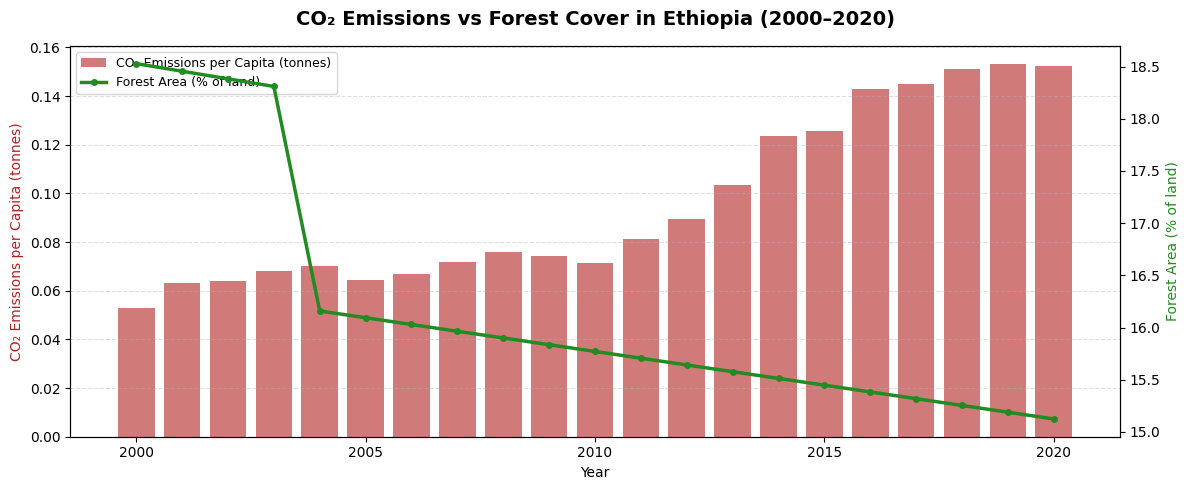

In [3]:
import matplotlib.pyplot as plt

# Chart 1: CO2 vs Forest Cover
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(df['Year'], df['CO2_Emissions_Per_Capita'],
        color='firebrick', alpha=0.6, label='CO₂ Emissions per Capita (tonnes)')
ax2.plot(df['Year'], df['Forest_Area_Pct'],
         color='forestgreen', linewidth=2.5, marker='o', markersize=4, label='Forest Area (% of land)')

ax1.set_title('CO₂ Emissions vs Forest Cover in Ethiopia (2000–2020)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year')
ax1.set_ylabel('CO₂ Emissions per Capita (tonnes)', color='firebrick')
ax2.set_ylabel('Forest Area (% of land)', color='forestgreen')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart1_co2_forest.png', dpi=150)
plt.show()

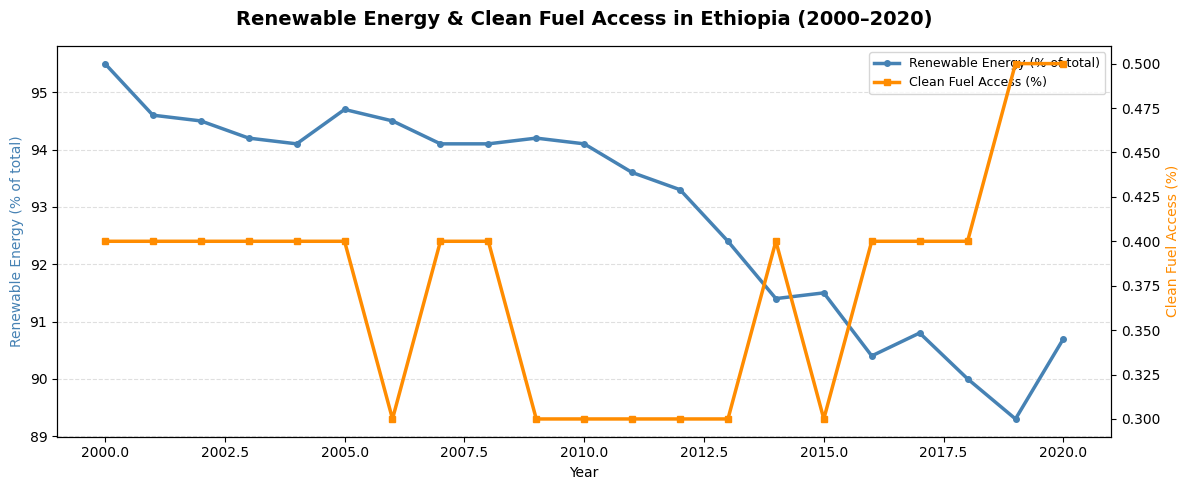

In [4]:
# Chart 2: Renewable Energy vs Clean Fuel Access
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(df['Year'], df['Renewable_Energy_Pct'],
         color='steelblue', linewidth=2.5, marker='o', markersize=4,
         label='Renewable Energy (% of total)')
ax2.plot(df['Year'], df['Clean_Fuel_Access_Pct'],
         color='darkorange', linewidth=2.5, marker='s', markersize=4,
         label='Clean Fuel Access (%)')

ax1.set_title('Renewable Energy & Clean Fuel Access in Ethiopia (2000–2020)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year')
ax1.set_ylabel('Renewable Energy (% of total)', color='steelblue')
ax2.set_ylabel('Clean Fuel Access (%)', color='darkorange')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_energy.png', dpi=150)
plt.show()

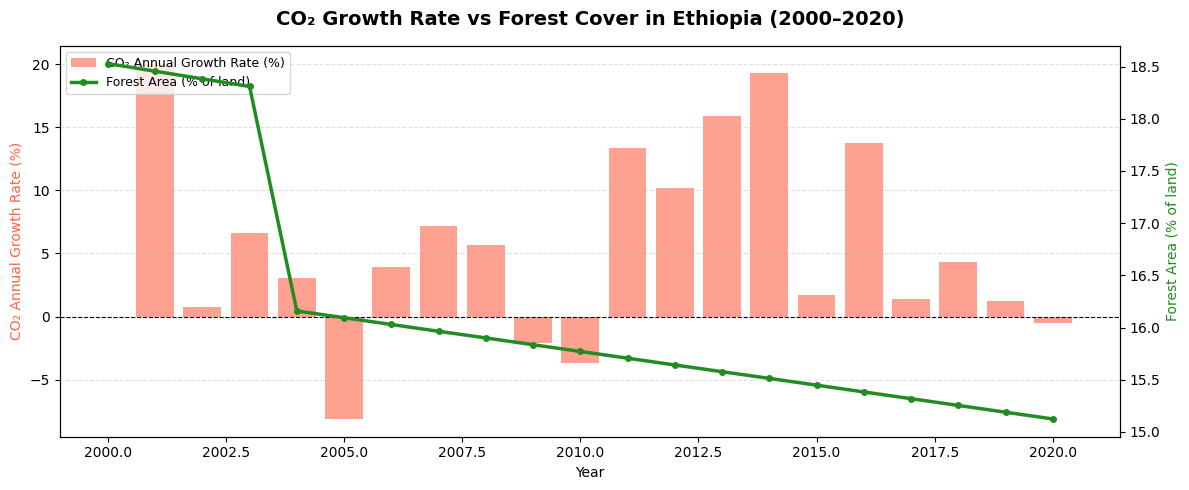

In [5]:
# Chart 3: CO2 Growth Rate vs Forest Cover
df['CO2_Growth'] = df['CO2_Emissions_Per_Capita'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(df['Year'], df['CO2_Growth'],
        color='tomato', alpha=0.6, label='CO₂ Annual Growth Rate (%)')
ax2.plot(df['Year'], df['Forest_Area_Pct'],
         color='forestgreen', linewidth=2.5, marker='o', markersize=4,
         label='Forest Area (% of land)')

ax1.set_title('CO₂ Growth Rate vs Forest Cover in Ethiopia (2000–2020)',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Year')
ax1.set_ylabel('CO₂ Annual Growth Rate (%)', color='tomato')
ax2.set_ylabel('Forest Area (% of land)', color='forestgreen')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart3_co2_growth.png', dpi=150)
plt.show()

In [6]:
# Download all files
from google.colab import files
files.download('Ethiopia_Carbon_Market.csv')
files.download('chart1_co2_forest.png')
files.download('chart2_energy.png')
files.download('chart3_co2_growth.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>